# Supplementary Check Figure Notebook  
## 04 — Newer/DTC vs Legacy/Premium Luggage Brands

This notebook reads the completed supplementary-check Comparison 01/02/03 result tables and makes **supplementary figures only**. It does **not** overwrite the main benchmark figure names.

The emphasis is the brand-type contrast requested for the supplementary check:

- **Newer / DTC-oriented brands:** Away, July
- **Legacy / premium luggage brands:** Briggs & Riley, Hartmann Century, RIMOWA

The figures are meant for robustness checking and discussion, not as the primary manuscript figures.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 350,
    "savefig.bbox": "tight",
    "savefig.facecolor": "white",
    "savefig.transparent": False,
    "font.family": "DejaVu Sans",
    "font.size": 8.0,
    "axes.titlesize": 9.0,
    "axes.labelsize": 8.2,
    "xtick.labelsize": 7.6,
    "ytick.labelsize": 7.6,
    "legend.fontsize": 7.5,
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 160)

def mm_to_inch(w, h):
    return (w / 25.4, h / 25.4)

# Internal product IDs should match the 01/02/03 supplementary notebooks.
PRODUCT_ORDER = ["Away", "July", "BR", "Century", "Rimowa"]
PRODUCT_DISPLAY = {
    "Away": "Away",
    "July": "July",
    "BR": "Briggs & Riley",
    "Century": "Hartmann Century",
    "Rimowa": "RIMOWA",
}
BRAND_GROUP = {
    "Away": "Newer / DTC",
    "July": "Newer / DTC",
    "BR": "Legacy / premium",
    "Century": "Legacy / premium",
    "Rimowa": "Legacy / premium",
}
GROUP_ORDER = ["Newer / DTC", "Legacy / premium"]

PRODUCT_ALIASES = {
    "away": "Away",
    "july": "July",
    "br": "BR",
    "briggs": "BR",
    "briggs & riley": "BR",
    "briggs and riley": "BR",
    "briggs riley": "BR",
    "century": "Century",
    "hartmann": "Century",
    "rimowa": "Rimowa",
    "rimowa essential": "Rimowa",
}

COMPARISON_LABELS = {
    "current_over_old": "Current over old",
    "geo_over_old": "GEO over old",
    "geo_over_current": "GEO over current",
}

# Use consistent, restrained colors for group figures.
GROUP_STYLE = {
    "Newer / DTC": {"color": "#2f6f9f", "marker": "o"},
    "Legacy / premium": {"color": "#8c5a2b", "marker": "s"},
}


## Locate result tables

Run this notebook from the supplementary-check repository root, `supplementary_check/`, `code/`, `results/`, or `results/tables/`. The search is intentionally flexible because the notebooks may be executed from VS Code or Jupyter.

In [2]:
def find_tables_dir(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    candidates = []

    for p in [start] + list(start.parents):
        candidates += [
            p,
            p / "results" / "tables",
            p / "data" / "results" / "tables",
            p / "code" / "data" / "results" / "tables",
            p / "supplementary_check" / "results" / "tables",
            p / "supplementary_check" / "data" / "results" / "tables",
            p / "supplementary_check" / "code" / "data" / "results" / "tables",
        ]

    # Shallow recursive fallback from likely roots.
    for base in [start, start.parent, start.parent.parent if start.parent else start]:
        if base.exists() and base.is_dir():
            candidates += list(base.glob("**/results/tables"))
            candidates += list(base.glob("**/code/data/results/tables"))

    seen, unique = set(), []
    for c in candidates:
        try:
            c = c.resolve()
        except Exception:
            continue
        if c not in seen:
            seen.add(c)
            unique.append(c)

    for c in unique:
        if c.exists() and c.is_dir():
            has_01 = any(child.is_dir() and child.name.startswith("01_") for child in c.iterdir())
            has_02 = any(child.is_dir() and child.name.startswith("02_") for child in c.iterdir())
            has_03 = any(child.is_dir() and child.name.startswith("03_") for child in c.iterdir())
            if has_01 and has_02 and has_03:
                return c

    checked = "\n".join(str(c) for c in unique[:80])
    raise FileNotFoundError("Could not find a results/tables directory containing 01_/02_/03_ subfolders. Checked:\n" + checked)


def find_csv(folder_prefix, file_name):
    matches = sorted(TABLES_DIR.glob(f"{folder_prefix}*/{file_name}"))
    if not matches:
        matches = [p for p in sorted(TABLES_DIR.glob(f"**/{file_name}")) if p.parent.name.startswith(folder_prefix)]
    if not matches:
        available = "\n".join(str(p.relative_to(TABLES_DIR)) for p in sorted(TABLES_DIR.glob("**/*.csv"))[:200])
        raise FileNotFoundError(f"Missing {file_name} under {folder_prefix}*. Available CSVs:\n{available}")
    return matches[0]

TABLES_DIR = find_tables_dir()
RESULTS_DIR = TABLES_DIR.parent
FIG_DIR = RESULTS_DIR / "figures" / "supplementary_check"
FIG_TABLE_DIR = TABLES_DIR / "supplementary_check_figure_outputs"
for d in [FIG_DIR, FIG_TABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

PATH_01 = find_csv("01_", "current_vs_baseline_delta_by_product.csv")
PATH_02 = find_csv("02_", "geo_vs_baseline_delta_by_product.csv")
PATH_03 = find_csv("03_", "geo_vs_current_delta_by_product.csv")

comp01 = pd.read_csv(PATH_01)
comp02 = pd.read_csv(PATH_02)
comp03 = pd.read_csv(PATH_03)

print("TABLES_DIR:", TABLES_DIR)
print("FIG_DIR:", FIG_DIR)
print("01:", PATH_01.relative_to(TABLES_DIR))
print("02:", PATH_02.relative_to(TABLES_DIR))
print("03:", PATH_03.relative_to(TABLES_DIR))
print("Shapes:", comp01.shape, comp02.shape, comp03.shape)


TABLES_DIR: C:\Users\junse\Documents\research\Finance Research\GEO_carry-on\supplementary_check\results\tables
FIG_DIR: C:\Users\junse\Documents\research\Finance Research\GEO_carry-on\supplementary_check\results\figures\supplementary_check
01: 01_2023_2024_original_vs_2026_current_baseline_based\current_vs_baseline_delta_by_product.csv
02: 02_2023_2024_original_vs_2023_2024_geo_rewrite_baseline_based\geo_vs_baseline_delta_by_product.csv
03: 03_2026_current_vs_2023_2024_geo_rewrite_baseline_current_chunked_based\geo_vs_current_delta_by_product.csv
Shapes: (5, 57) (5, 57) (5, 57)


## Normalize products and build the supplementary summary table

In [3]:
def normalize_product(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    lower = s.lower().replace("_", " ").replace("-", " ")
    compact = lower.replace(" ", "")

    # Direct and contains-based matching.
    if lower in PRODUCT_ALIASES:
        return PRODUCT_ALIASES[lower]
    if compact in PRODUCT_ALIASES:
        return PRODUCT_ALIASES[compact]
    for alias, canonical in PRODUCT_ALIASES.items():
        if alias in lower or alias.replace(" ", "") in compact:
            return canonical
    return s


def infer_product_col(df):
    for c in ["product", "Product", "product_label", "label", "brand", "Brand"]:
        if c in df.columns:
            return c
    best_col, best_score = None, -1
    for c in df.columns:
        vals = df[c].astype(str).str.lower().head(100)
        score = sum(any(alias in v for alias in PRODUCT_ALIASES) for v in vals)
        if score > best_score:
            best_col, best_score = c, score
    if best_col is None or best_score <= 0:
        raise ValueError(f"Could not infer product column. Columns: {list(df.columns)}")
    return best_col


def get_col(df, candidates, contains_all=None):
    for c in candidates:
        if c in df.columns:
            return c
    if contains_all:
        for c in df.columns:
            lc = c.lower()
            if all(tok in lc for tok in contains_all):
                return c
    return None


def product_metric(df, value_col, out_col):
    pcol = infer_product_col(df)
    if value_col is None:
        return pd.DataFrame(columns=["product", out_col])
    out = df[[pcol, value_col]].copy()
    out.columns = ["product", out_col]
    out["product"] = out["product"].map(normalize_product)
    out[out_col] = pd.to_numeric(out[out_col], errors="coerce")
    out = out.dropna(subset=["product", out_col])
    return out.groupby("product", as_index=False)[out_col].mean()

col_01 = get_col(comp01, ["current_page_advantage_score", "current_over_old_advantage_score"], contains_all=["advantage"])
col_02 = get_col(comp02, ["geo_rewrite_advantage_score", "geo_over_old_advantage_score"], contains_all=["advantage"])
col_03 = get_col(comp03, ["geo_vs_current_advantage_score", "geo_over_current_advantage_score"], contains_all=["geo", "current", "advantage"])

summary = product_metric(comp01, col_01, "current_over_old")
summary = summary.merge(product_metric(comp02, col_02, "geo_over_old"), on="product", how="outer")
summary = summary.merge(product_metric(comp03, col_03, "geo_over_current"), on="product", how="outer")

summary["product"] = summary["product"].map(normalize_product)
summary = summary[summary["product"].isin(PRODUCT_ORDER)].copy()
summary["product_display"] = summary["product"].map(PRODUCT_DISPLAY)
summary["brand_group"] = summary["product"].map(BRAND_GROUP)
summary["order"] = summary["product"].map({p: i for i, p in enumerate(PRODUCT_ORDER)})
summary = summary.sort_values("order").drop(columns="order").reset_index(drop=True)
summary["current_minus_geo_old_effect"] = summary["current_over_old"] - summary["geo_over_old"]
summary["same_direction_old_baseline"] = np.sign(summary["current_over_old"]) == np.sign(summary["geo_over_old"])

summary.to_csv(FIG_TABLE_DIR / "supplementary_check_product_summary_newer_vs_legacy.csv", index=False)
display(summary)


,product,current_over_old,geo_over_old,geo_over_current,product_display,brand_group,current_minus_geo_old_effect,same_direction_old_baseline
0,Away,0.005998,0.024866,0.103930,Away,Newer / DTC,-0.018868,True
1,July,0.045990,0.055001,0.008549,July,Newer / DTC,-0.009011,True
2,BR,0.061126,0.064747,-0.040820,Briggs & Riley,Legacy / premium,-0.003621,True
3,Century,0.028160,0.002707,-0.085725,Hartmann Century,Legacy / premium,0.025453,True
4,Rimowa,-0.078227,-0.014392,0.068070,RIMOWA,Legacy / premium,-0.063835,True


In [4]:
# Long table for plotting and group aggregation.
long = summary.melt(
    id_vars=["product", "product_display", "brand_group"],
    value_vars=["current_over_old", "geo_over_old", "geo_over_current"],
    var_name="comparison",
    value_name="advantage_score",
).dropna(subset=["advantage_score"])
long["comparison_label"] = long["comparison"].map(COMPARISON_LABELS)
long["comparison_order"] = long["comparison"].map({"current_over_old": 0, "geo_over_old": 1, "geo_over_current": 2})
long["group_order"] = long["brand_group"].map({g: i for i, g in enumerate(GROUP_ORDER)})
long["product_order"] = long["product"].map({p: i for i, p in enumerate(PRODUCT_ORDER)})
long = long.sort_values(["comparison_order", "group_order", "product_order"])

# Group means and ranges. With n=2 for newer/DTC and n=3 for legacy/premium, treat these as descriptive only.
group_summary = (
    long.groupby(["comparison", "comparison_label", "brand_group"], as_index=False)
    .agg(
        mean_advantage=("advantage_score", "mean"),
        min_advantage=("advantage_score", "min"),
        max_advantage=("advantage_score", "max"),
        n_products=("product", "nunique"),
    )
)
group_summary["comparison_order"] = group_summary["comparison"].map({"current_over_old": 0, "geo_over_old": 1, "geo_over_current": 2})
group_summary["group_order"] = group_summary["brand_group"].map({g: i for i, g in enumerate(GROUP_ORDER)})
group_summary = group_summary.sort_values(["comparison_order", "group_order"])

group_summary.to_csv(FIG_TABLE_DIR / "supplementary_check_group_summary_newer_vs_legacy.csv", index=False)
display(group_summary)


,comparison,comparison_label,brand_group,mean_advantage,min_advantage,max_advantage,n_products,comparison_order,group_order
1,current_over_old,Current over old,Newer / DTC,0.025994,0.005998,0.045990,2,0,0
0,current_over_old,Current over old,Legacy / premium,0.003686,-0.078227,0.061126,3,0,1
5,geo_over_old,GEO over old,Newer / DTC,0.039934,0.024866,0.055001,2,1,0
4,geo_over_old,GEO over old,Legacy / premium,0.017687,-0.014392,0.064747,3,1,1
3,geo_over_current,GEO over current,Newer / DTC,0.056239,0.008549,0.103930,2,2,0
2,geo_over_current,GEO over current,Legacy / premium,-0.019492,-0.085725,0.068070,3,2,1


In [5]:
def save_pdf_png(fig, out_base, show=True):
    out_base = Path(out_base)
    out_base.parent.mkdir(parents=True, exist_ok=True)
    pdf_path = out_base.with_suffix(".pdf")
    png_path = out_base.with_suffix(".png")
    fig.savefig(pdf_path, bbox_inches="tight", facecolor="white", transparent=False)
    fig.savefig(png_path, bbox_inches="tight", facecolor="white", transparent=False, dpi=350)
    plt.close(fig)
    print("Saved:", pdf_path)
    print("Saved:", png_path)
    if show:
        display(Image(filename=str(png_path)))


## Supplementary Figure A — Product-level effects grouped by brand type

This figure is intentionally group-first: products are ordered as newer/DTC first, then established legacy/premium brands. It is useful for checking whether the supplementary brand set shows a different direction than the main five-product benchmark.

Saved: C:\Users\junse\Documents\research\Finance Research\GEO_carry-on\supplementary_check\results\figures\supplementary_check\supp_check_figureA_product_effects_newer_vs_legacy.pdf
Saved: C:\Users\junse\Documents\research\Finance Research\GEO_carry-on\supplementary_check\results\figures\supplementary_check\supp_check_figureA_product_effects_newer_vs_legacy.png


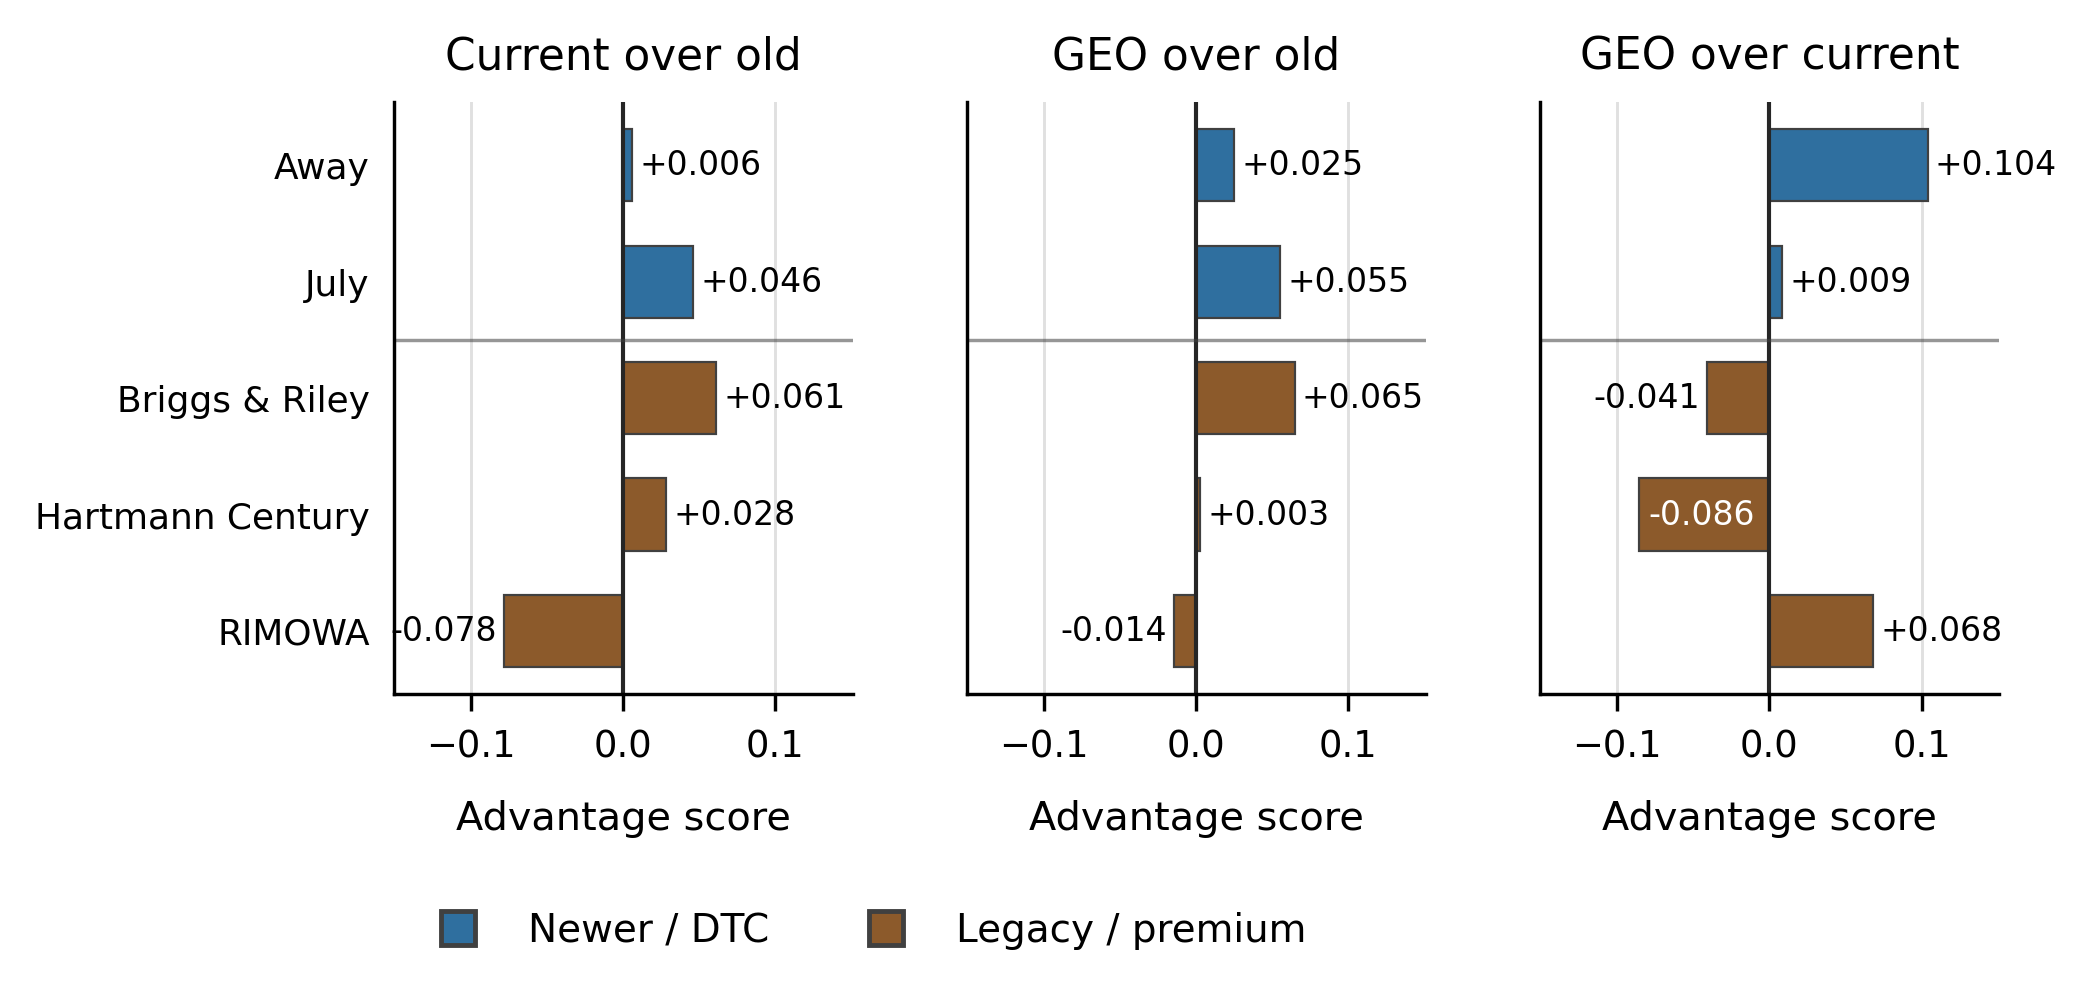

In [15]:
fig, axes = plt.subplots(1, 3, figsize=mm_to_inch(170, 74), sharey=True)
comparison_order = ["current_over_old", "geo_over_old", "geo_over_current"]

# Shared x-limit across panels
global_span = max(
    float(np.nanmax(np.abs(long["advantage_score"].to_numpy(float)))),
    0.05
)
xlim = global_span * 1.45
label_offset = global_span * 0.045

for ax, comp in zip(axes, comparison_order):
    sub = long[long["comparison"] == comp].sort_values(["group_order", "product_order"]).reset_index(drop=True)
    ypos = np.arange(len(sub))
    vals = sub["advantage_score"].to_numpy(float)
    colors = [GROUP_STYLE[g]["color"] for g in sub["brand_group"]]

    ax.barh(
        ypos,
        vals,
        color=colors,
        edgecolor="0.25",
        linewidth=0.45,
        height=0.62,
    )

    ax.axvline(0, color="0.15", linewidth=0.85)
    ax.set_title(COMPARISON_LABELS[comp], pad=7)
    ax.set_xlabel("Advantage score", labelpad=7)
    ax.grid(axis="x", color="0.88", linewidth=0.6)
    ax.set_axisbelow(True)

    ax.set_yticks(ypos)

    if ax is axes[0]:
        ax.set_yticklabels(sub["product_display"].tolist(), fontsize=7.4)
        ax.tick_params(axis="y", length=0, pad=5, labelleft=True)
    else:
        ax.tick_params(axis="y", length=0, labelleft=False)

    ax.invert_yaxis()

    # Separator between newer/DTC and legacy/premium groups
    if len(sub) > 2:
        ax.axhline(1.5, color="0.25", linewidth=0.7, alpha=0.55)

    ax.set_xlim(-xlim, xlim)

    for y, val in zip(ypos, vals):
        product_name = sub.loc[y, "product_display"]

        # Default: labels outside in black
        inside_special = (comp == "geo_over_current") and (product_name == "Hartmann Century") and np.isclose(val, -0.086, atol=5e-4)

        if inside_special:
            # Put only -0.086 inside the bar in white
            x_text = val * 0.52
            ha = "center"
            text_color = "white"
            fontweight = "normal"
        else:
            if val >= 0:
                x_text = val + label_offset
                ha = "left"
            else:
                x_text = val - label_offset
                ha = "right"
            text_color = "black"
            fontweight = "normal"

        ax.text(
            x_text,
            y,
            f"{val:+.3f}",
            va="center",
            ha=ha,
            fontsize=6.8,
            color=text_color,
            fontweight=fontweight,
            clip_on=False,
        )

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

handles = [
    plt.Line2D(
        [0],
        [0],
        marker="s",
        linestyle="",
        markersize=7,
        markerfacecolor=GROUP_STYLE[g]["color"],
        markeredgecolor="0.25",
        label=g,
    )
    for g in GROUP_ORDER
]

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.015),
    fontsize=8.0,
)

fig.subplots_adjust(
    left=0.30,
    right=0.985,
    top=0.88,
    bottom=0.30,
    wspace=0.25,
)

save_pdf_png(fig, FIG_DIR / "supp_check_figureA_product_effects_newer_vs_legacy")

## Supplementary Figure B — Group mean with within-group range

Because the supplementary check has only five products, this plot uses descriptive group means and within-group min–max ranges rather than inferential confidence intervals.

Saved: C:\Users\junse\Documents\research\Finance Research\GEO_carry-on\supplementary_check\results\figures\supplementary_check\supp_check_figureB_group_mean_range_newer_vs_legacy.pdf
Saved: C:\Users\junse\Documents\research\Finance Research\GEO_carry-on\supplementary_check\results\figures\supplementary_check\supp_check_figureB_group_mean_range_newer_vs_legacy.png


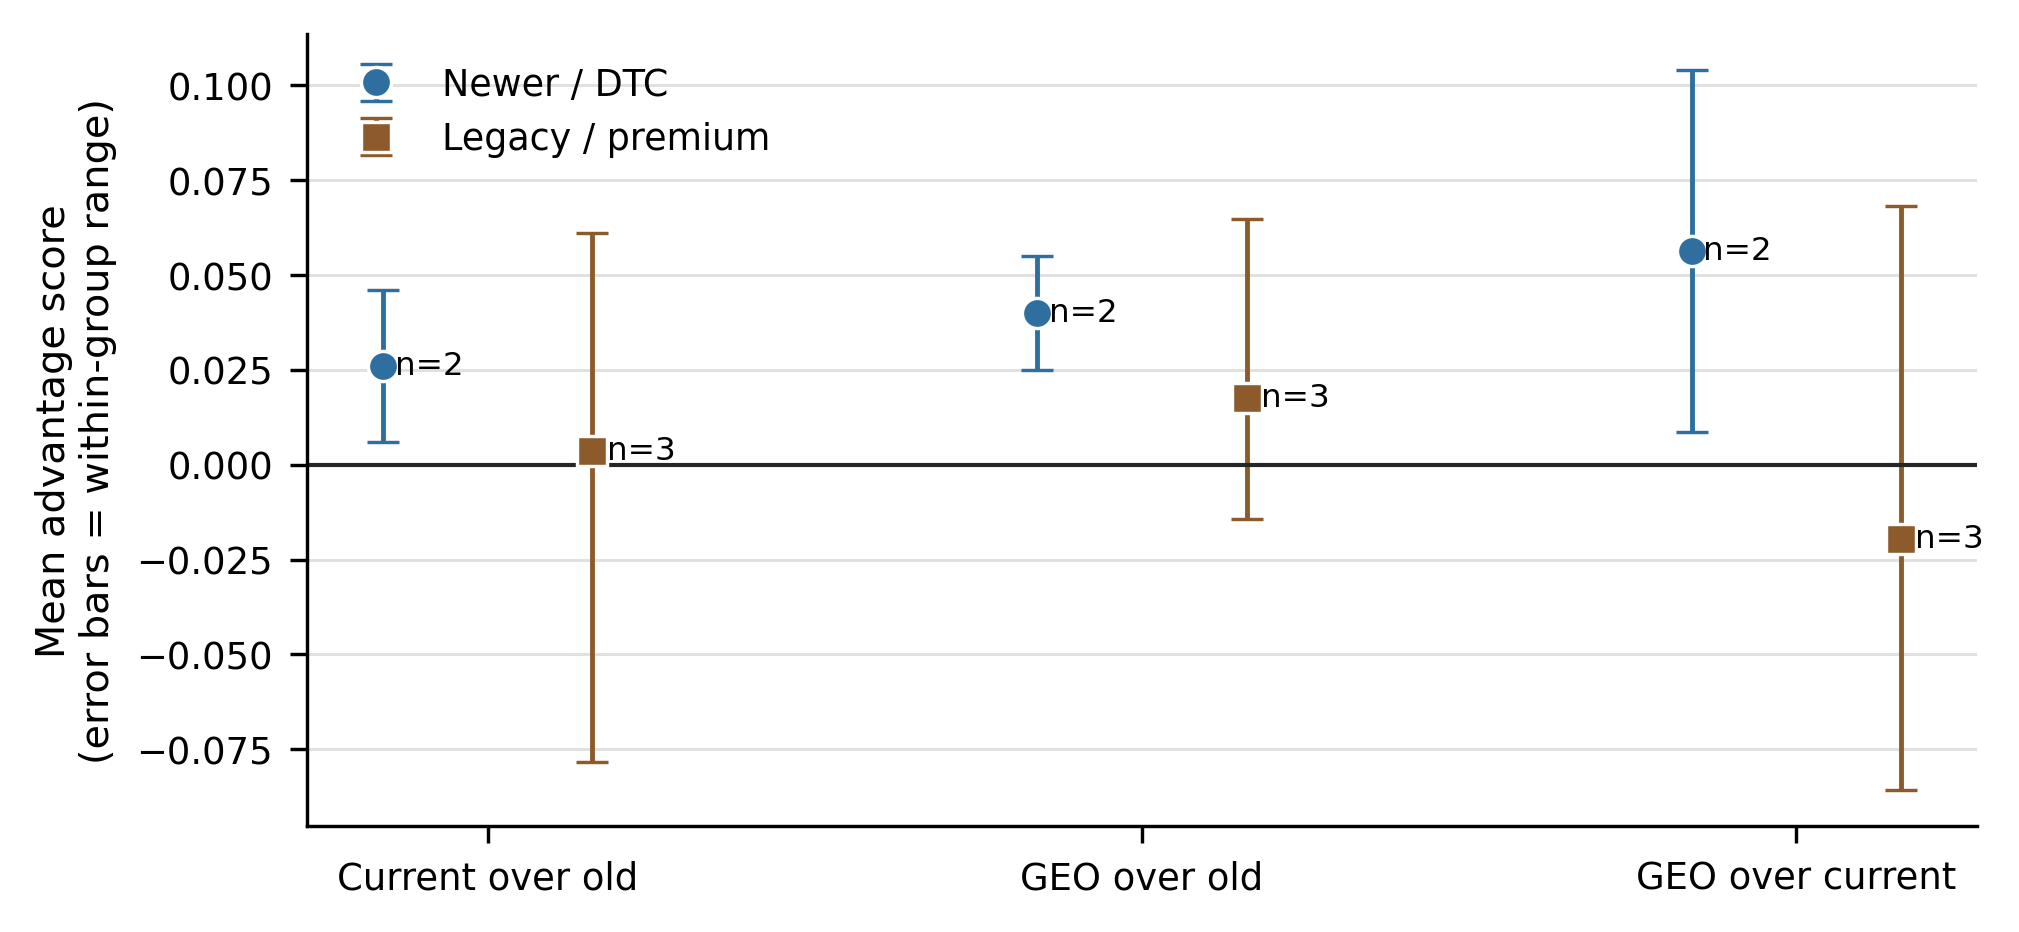

In [17]:
fig, ax = plt.subplots(figsize=mm_to_inch(145, 65))

x_base = np.arange(len(comparison_order))
offset = 0.16

for gi, group in enumerate(GROUP_ORDER):
    sub = (
        group_summary[group_summary["brand_group"] == group]
        .set_index("comparison")
        .reindex(comparison_order)
        .reset_index()
    )

    x = x_base + (-offset if gi == 0 else offset)
    y = sub["mean_advantage"].to_numpy(float)
    ymin = sub["min_advantage"].to_numpy(float)
    ymax = sub["max_advantage"].to_numpy(float)
    yerr = np.vstack([y - ymin, ymax - y])

    style = GROUP_STYLE[group]
    ax.errorbar(
        x, y, yerr=yerr,
        fmt=style["marker"], markersize=6.2,
        color=style["color"], ecolor=style["color"],
        elinewidth=1.0, capsize=3.2, label=group,
        markeredgecolor="white", markeredgewidth=0.7,
    )

    # Move count labels a bit to the right so they do not overlap the markers
    text_dx = 0.018 if gi == 0 else 0.022

    for xx, yy, n in zip(x, y, sub["n_products"]):
        if np.isfinite(yy):
            ax.text(
                xx + text_dx,
                yy,
                f"n={int(n)}",
                fontsize=6.7,
                va="center",
                ha="left",
            )

ax.axhline(0, color="0.15", linewidth=0.85)
ax.set_xticks(x_base)
ax.set_xticklabels([COMPARISON_LABELS[c] for c in comparison_order])
ax.set_ylabel("Mean advantage score\n(error bars = within-group range)")
ax.grid(axis="y", color="0.88", linewidth=0.6)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc="best")

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

fig.tight_layout(pad=0.45)

save_pdf_png(fig, FIG_DIR / "supp_check_figureB_group_mean_range_newer_vs_legacy")


## Supplementary Figure C — Observed current movement vs hypothetical GEO movement by brand type

This mirrors the alignment logic from the main benchmark, but the labels and marker groups highlight whether newer/DTC and legacy/premium products occupy different regions.

Saved: C:\Users\junse\Documents\research\Finance Research\GEO_carry-on\supplementary_check\results\figures\supplementary_check\supp_check_figureC_alignment_newer_vs_legacy.pdf
Saved: C:\Users\junse\Documents\research\Finance Research\GEO_carry-on\supplementary_check\results\figures\supplementary_check\supp_check_figureC_alignment_newer_vs_legacy.png


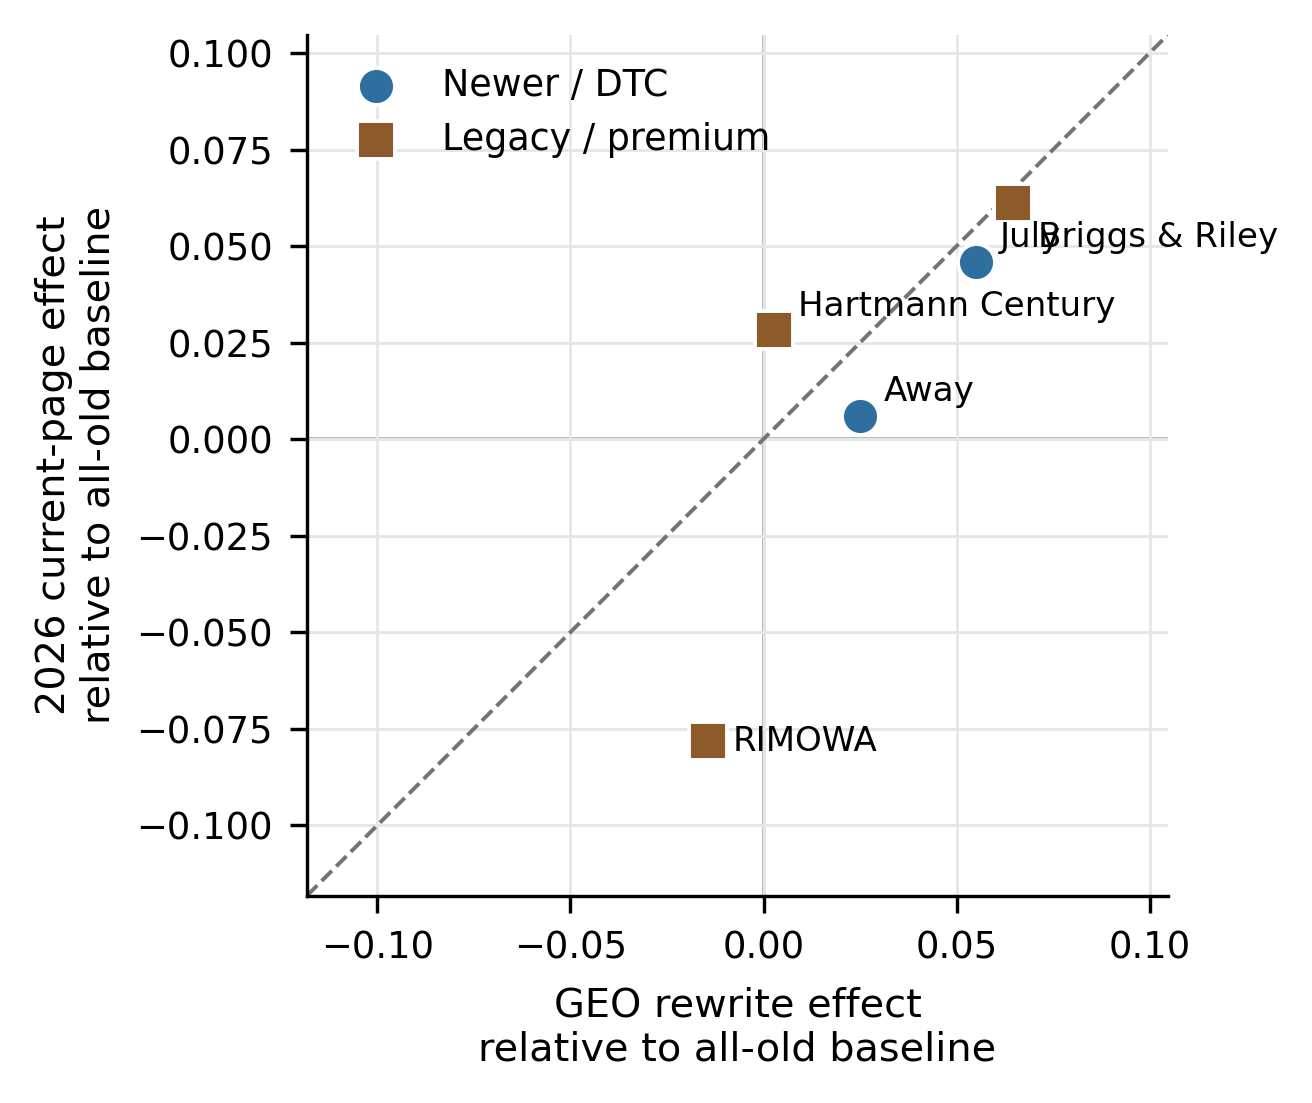

In [8]:
scatter_df = summary.dropna(subset=["geo_over_old", "current_over_old"]).copy()
fig, ax = plt.subplots(figsize=mm_to_inch(95, 78))

x = scatter_df["geo_over_old"].to_numpy(float)
y = scatter_df["current_over_old"].to_numpy(float)
finite = np.concatenate([x[np.isfinite(x)], y[np.isfinite(y)]]) if len(scatter_df) else np.array([0])
lo = min(float(finite.min()) - 0.04, -0.02)
hi = max(float(finite.max()) + 0.04, 0.02)

ax.axhline(0, color="0.72", linewidth=0.8, zorder=0)
ax.axvline(0, color="0.72", linewidth=0.8, zorder=0)
ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=0.8, color="0.45", zorder=1)

for group in GROUP_ORDER:
    sub = scatter_df[scatter_df["brand_group"] == group]
    style = GROUP_STYLE[group]
    ax.scatter(
        sub["geo_over_old"], sub["current_over_old"],
        s=58, marker=style["marker"], color=style["color"],
        edgecolor="white", linewidth=0.8, label=group, zorder=3,
    )

for _, row in scatter_df.iterrows():
    label = row["product_display"]
    dx, dy = (5, 5)
    if row["product"] == "BR":
        dx, dy = (5, -7)
    if row["product"] == "Rimowa":
        dx, dy = (5, 0)
    ax.annotate(label, xy=(row["geo_over_old"], row["current_over_old"]),
                xytext=(dx, dy), textcoords="offset points", fontsize=7.0, ha="left", va="center")

ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("GEO rewrite effect\nrelative to all-old baseline")
ax.set_ylabel("2026 current-page effect\nrelative to all-old baseline")
ax.grid(True, color="0.90", linewidth=0.6)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc="best")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
fig.tight_layout(pad=0.45)

save_pdf_png(fig, FIG_DIR / "supp_check_figureC_alignment_newer_vs_legacy")


## Optional Supplementary Figure D — Provider-style visibility delta by group

This figure is created only if the updated 01/02/03 tables contain provider-style visibility columns. It is still based on controlled product-label answers, so it should be described as **answer-level provider-style metrics**, not real external domain/source tracking.

,comparison,comparison_label,brand_group,mean_provider_delta,n_products,comparison_order,group_order
1,current_over_old,Current over old,Newer / DTC,0.025994,2,0,0
0,current_over_old,Current over old,Legacy / premium,0.003686,3,0,1
5,geo_over_old,GEO over old,Newer / DTC,0.039934,2,1,0
4,geo_over_old,GEO over old,Legacy / premium,0.017687,3,1,1
3,geo_over_current,GEO over current,Newer / DTC,0.056239,2,2,0
2,geo_over_current,GEO over current,Legacy / premium,-0.019492,3,2,1


Saved: C:\Users\junse\Documents\research\Finance Research\GEO_carry-on\supplementary_check\results\figures\supplementary_check\supp_check_figureD_provider_style_group_delta.pdf
Saved: C:\Users\junse\Documents\research\Finance Research\GEO_carry-on\supplementary_check\results\figures\supplementary_check\supp_check_figureD_provider_style_group_delta.png


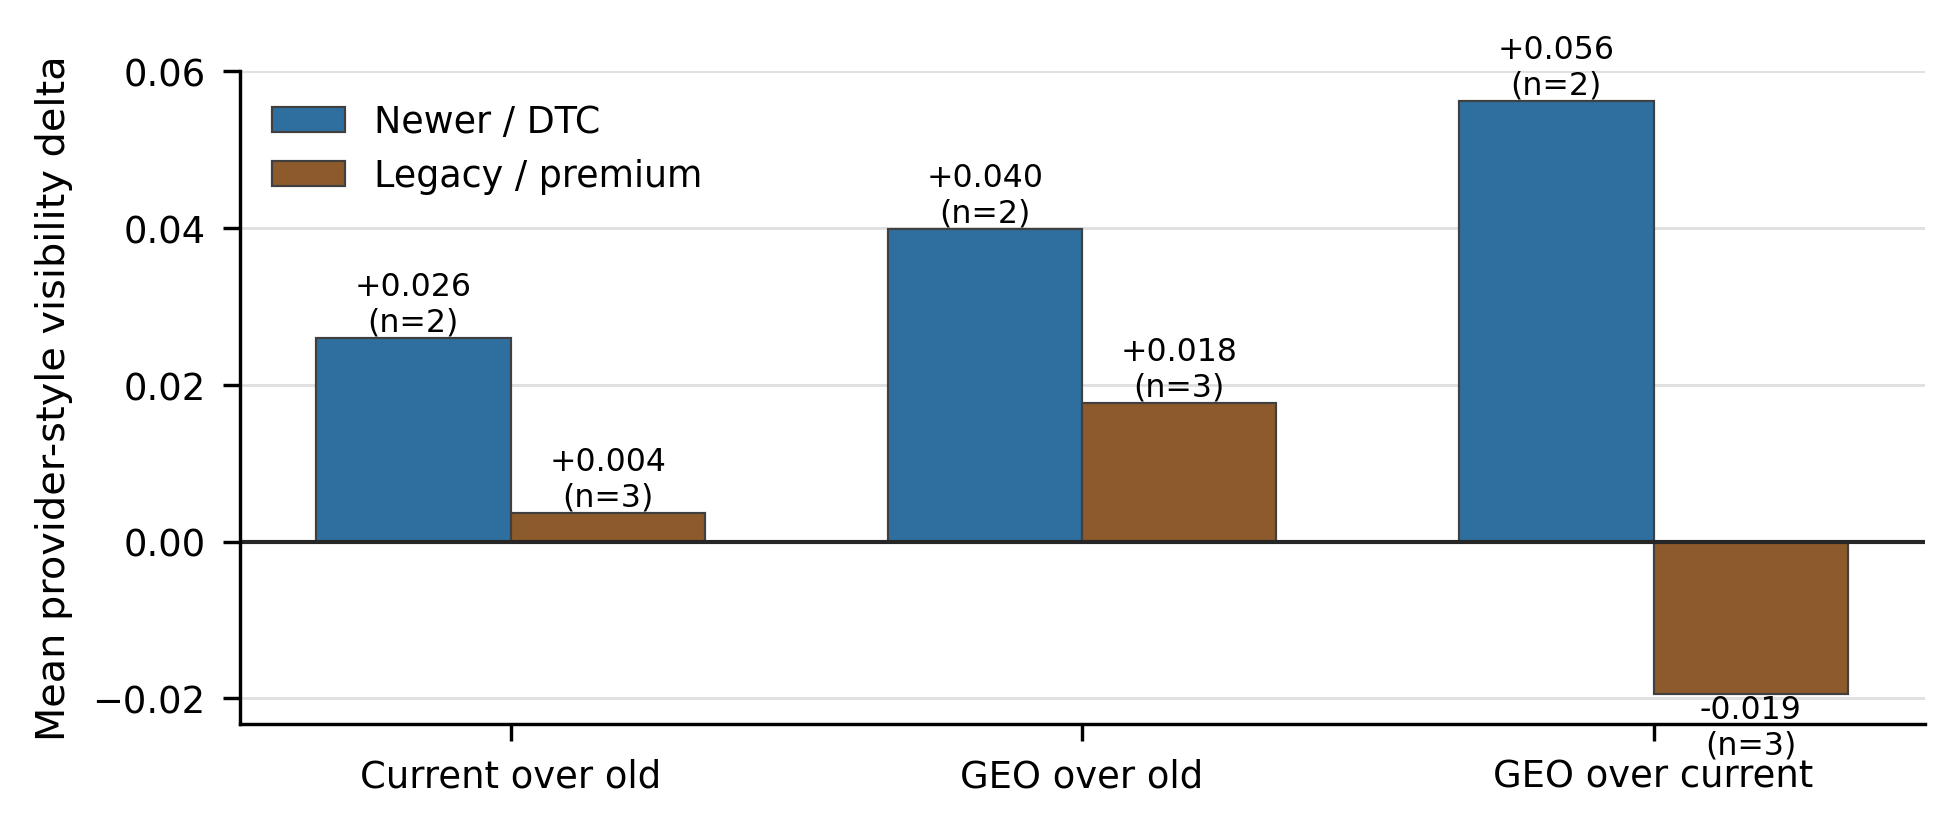

In [9]:
PROVIDER_COL_CANDIDATES = {
    "current_over_old": ["historical_visibility_delta", "provider_style_visibility_delta"],
    "geo_over_old": ["replacement_visibility_delta", "provider_style_visibility_delta"],
    "geo_over_current": ["replacement_visibility_delta", "provider_style_visibility_delta"],
}

def provider_product_metric(df, comparison_key):
    value_col = None
    for c in PROVIDER_COL_CANDIDATES[comparison_key]:
        if c in df.columns:
            value_col = c
            break
    if value_col is None:
        return None
    out = product_metric(df, value_col, comparison_key)
    return out

prov_frames = []
for df, comp in [(comp01, "current_over_old"), (comp02, "geo_over_old"), (comp03, "geo_over_current")]:
    m = provider_product_metric(df, comp)
    if m is not None and not m.empty:
        m = m.rename(columns={comp: "provider_style_delta"})
        m["comparison"] = comp
        prov_frames.append(m)

if not prov_frames:
    print("No provider-style visibility delta columns found; skipping Figure D.")
else:
    prov = pd.concat(prov_frames, ignore_index=True)
    prov = prov[prov["product"].isin(PRODUCT_ORDER)].copy()
    prov["product_display"] = prov["product"].map(PRODUCT_DISPLAY)
    prov["brand_group"] = prov["product"].map(BRAND_GROUP)
    prov["comparison_label"] = prov["comparison"].map(COMPARISON_LABELS)
    prov["comparison_order"] = prov["comparison"].map({"current_over_old": 0, "geo_over_old": 1, "geo_over_current": 2})
    prov["product_order"] = prov["product"].map({p: i for i, p in enumerate(PRODUCT_ORDER)})
    prov.to_csv(FIG_TABLE_DIR / "supplementary_check_provider_style_product_summary.csv", index=False)

    prov_group = (
        prov.groupby(["comparison", "comparison_label", "brand_group"], as_index=False)
        .agg(mean_provider_delta=("provider_style_delta", "mean"), n_products=("product", "nunique"))
    )
    prov_group["comparison_order"] = prov_group["comparison"].map({"current_over_old": 0, "geo_over_old": 1, "geo_over_current": 2})
    prov_group["group_order"] = prov_group["brand_group"].map({g: i for i, g in enumerate(GROUP_ORDER)})
    prov_group = prov_group.sort_values(["comparison_order", "group_order"])
    display(prov_group)

    fig, ax = plt.subplots(figsize=mm_to_inch(140, 58))
    width = 0.34
    x_base = np.arange(len(comparison_order))
    for gi, group in enumerate(GROUP_ORDER):
        sub = prov_group[prov_group["brand_group"] == group].set_index("comparison").reindex(comparison_order).reset_index()
        x = x_base + (-width/2 if gi == 0 else width/2)
        vals = sub["mean_provider_delta"].to_numpy(float)
        ax.bar(x, vals, width=width, color=GROUP_STYLE[group]["color"], edgecolor="0.25", linewidth=0.45, label=group)
        for xx, vv, n in zip(x, vals, sub["n_products"]):
            if np.isfinite(vv):
                va = "bottom" if vv >= 0 else "top"
                ax.text(xx, vv, f"{vv:+.3f}\n(n={int(n)})", ha="center", va=va, fontsize=6.5)

    ax.axhline(0, color="0.15", linewidth=0.85)
    ax.set_xticks(x_base)
    ax.set_xticklabels([COMPARISON_LABELS[c] for c in comparison_order])
    ax.set_ylabel("Mean provider-style visibility delta")
    ax.grid(axis="y", color="0.88", linewidth=0.6)
    ax.set_axisbelow(True)
    ax.legend(frameon=False, loc="best")
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    fig.tight_layout(pad=0.45)
    save_pdf_png(fig, FIG_DIR / "supp_check_figureD_provider_style_group_delta")


## Suggested caption language

**Supplementary check figure caption draft:**  
Product-level and group-level one-product replacement effects for an additional luggage-brand set, comparing newer/DTC-oriented brands (Away and July) with established legacy/premium brands (Briggs & Riley, Hartmann Century, and RIMOWA). Positive values indicate stronger answer behavior for the replacement condition relative to the relevant baseline. Group summaries are descriptive because the supplementary check contains only five products.